In [22]:
import pandas as pd
import os
import torch
import json
import numpy as np
import collections
import re
import matplotlib.pyplot as plt

In [9]:
def get_indiv_concepts(df) -> set:
    concepts= set()
    expls = [form for form in df.best_name]
    expls = " ".join(expls)
    concps = re.findall(r'\b(?:NOT )?(?:pre:tok:|pre:tag:|hyp:tag:|hyp:tok:|oth:)\S*', expls)
    for i,_ in enumerate(concps):
        while concps[i][-1] == ')':
            concps[i] = concps[i][:-1]
        concepts.add(concps[i])
    return concepts

In [17]:
expls_dir = "/workspace/CCE_NLI/BOWMAN/exp/bowman/lottery_ticket/Run2Full/Expls" 
expls_dir = "/workspace/CCE_NLI/BERT/exp/bert/lottery_ticket/Run2Full/Expls"
all_cps = collections.defaultdict(dict)
for pruning_iter in os.listdir(expls_dir):
    for cluster in range(1,4):
        df = pd.read_csv(os.path.join(expls_dir, pruning_iter, f'Cluster{cluster}IOUS1024N.csv'))
        concepts = get_indiv_concepts(df)
        all_cps[cluster][pruning_iter] = concepts
        

13


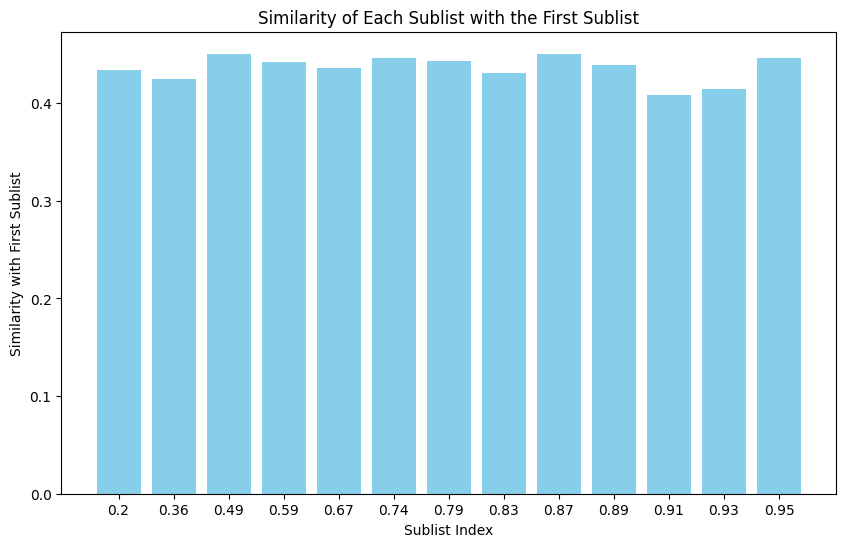

13


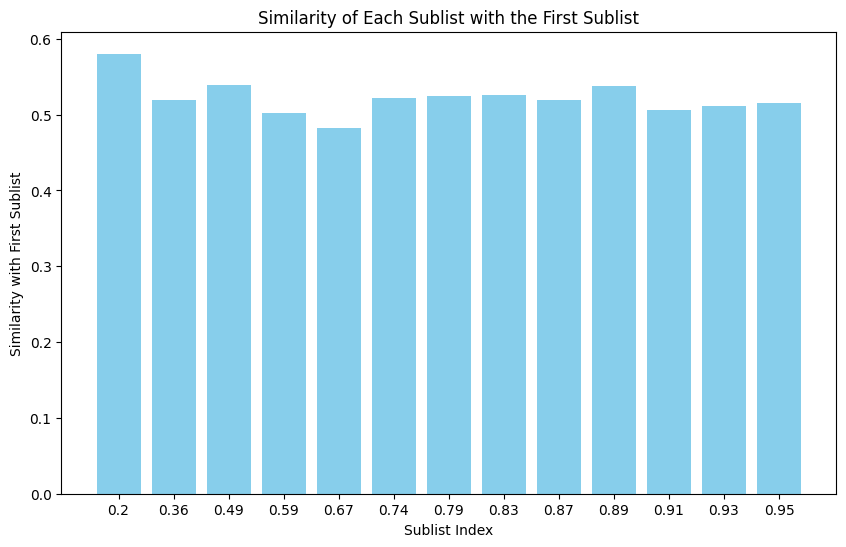

13


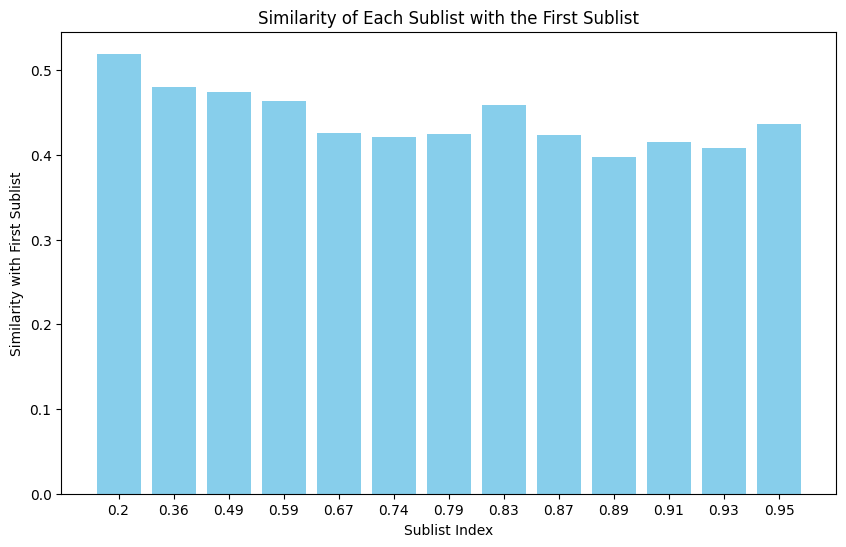

In [29]:
def quantify_similarity(big_list):
    if not big_list:
        return []  # Return empty list if input is empty
    
    # Get the first sublist as the reference
    reference_set = set(big_list[0])
    
    similarities = []
    for sublist in big_list[1:]:
        # Convert the current sublist to a set
        current_set = set(sublist)
        
        # Calculate Jaccard similarity: intersection / union
        intersection = len(reference_set.intersection(current_set))
        union = len(reference_set.union(current_set))
        
        # Avoid division by zero (if both sets are empty)
        similarity = intersection / union if union != 0 else 0.0
        
        similarities.append(similarity)
    
    return similarities
def find_common_concepts(big_list):
    # Check if the big list is empty or has no sublists
    if not big_list:
        return []
    
    # Convert the first sublist to a set
    common_concepts = set(big_list[0])
    
    # Iterate over the remaining sublists and find the intersection
    for sublist in big_list[1:]:
        common_concepts.intersection_update(sublist)
    
    # Convert the set back to a list and return it
    return list(common_concepts)

def plot_similarities(similarities):
    SPARSITY_RATIOS = [0.2, 0.36, 0.4879999603599318, 0.5903999682879455, 0.6723199349902882, 0.7378560669124351, 0.7902848138898799, 0.832227870931938, 0.8657822967455504, 0.8926258572164744, 0.914100765053316, 0.9312805724025845, 0.9450244777421017, 0.9560195425536132]
    # Create a bar plot
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(similarities)), similarities, color='skyblue')
    
    # Add labels and title
    plt.xlabel('Sublist Index')
    plt.ylabel('Similarity with First Sublist')
    plt.title('Similarity of Each Sublist with the First Sublist')
    
    # Add x-axis ticks for each sublist
    plt.xticks(range(len(similarities)), labels=[np.round(SPARSITY_RATIOS[i],2) for i in range(0,len(similarities))])
    
    # Show the plot
    plt.show()

for clus in all_cps.keys():
    concepts=[]
    for pi in all_cps[clus].keys():
        concepts.append(all_cps[clus][pi])
    
    sims = quantify_similarity(concepts)
    print(len(sims))
    plot_similarities(sims)